# Problem Set 6 — MIT 6.7220/15.084 Nonlinear Optimization (Spring 2026)
**Nikhilesh Belulkar**

---

## Problem 1: Proximal Gradient and Acceleration

Consider the $\ell_1$-regularized regression problem:
$$\min_x \; \frac{1}{2}\|Ax - b\|_2^2 + \lambda\|x\|_1 \tag{1}$$
where $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$, and $\lambda > 0$.

### Question 1 (10 points): Proximal Operator of $g(x) = \lambda|x|$

We want to find:
$$\text{prox}_g(x) = \arg\min_y \left\{ \lambda|y| + \frac{1}{2}(y - x)^2 \right\}$$

We consider three cases based on the sign of $y$.

---

**Case 1: $y > 0$**

The objective becomes $h(y) = \lambda y + \frac{1}{2}(y-x)^2$. Setting the derivative to zero:
$$\frac{\partial h}{\partial y} = \lambda + (y - x) = 0 \implies y^* = x - \lambda$$

This is valid only when $y^* \geq 0$, i.e., $x \geq \lambda$. Therefore $\text{prox}_g(x) = x - \lambda$ for $x \geq \lambda$.

---

**Case 2: $y < 0$**

The objective becomes $h(y) = -\lambda y + \frac{1}{2}(y-x)^2$. Setting the derivative to zero:
$$\frac{\partial h}{\partial y} = -\lambda + (y - x) = 0 \implies y^* = x + \lambda$$

This is valid only when $y^* \leq 0$, i.e., $x \leq -\lambda$. Therefore $\text{prox}_g(x) = x + \lambda$ for $x \leq -\lambda$.

---

**Case 3: $y = 0$**

We use the subdifferential optimality condition $0 \in \partial_y\!\left[\lambda|y| + \frac{1}{2}(y-x)^2\right]\!\big|_{y=0}$. Since $\partial|y|\big|_{y=0} = [-1, 1]$:
$$0 \in \lambda[-1, 1] + (0 - x) \iff x \in [-\lambda, \lambda]$$

Therefore $\text{prox}_g(x) = 0$ for $|x| \leq \lambda$.

---

**Result — Soft-Thresholding Operator $\mathcal{S}_\lambda$:**

$$\boxed{\text{prox}_g(x) = \mathcal{S}_\lambda(x) = \begin{cases} x - \lambda & \text{if } x > \lambda \\ 0 & \text{if } |x| \leq \lambda \\ x + \lambda & \text{if } x < -\lambda \end{cases}}$$

**Why is $\text{prox}_g$ called a soft-thresholding function?**

It provides a threshold $\lambda$: any input with $|x| \leq \lambda$ is mapped to exactly zero (shrunk all the way), while inputs outside $[-\lambda, \lambda]$ are shifted toward zero by $\lambda$. This is "soft" because values above the threshold are not kept unchanged (as in hard-thresholding) but are continuously shrunk—making $\mathcal{S}_\lambda$ a Lipschitz-continuous function whose subdifferential is well-defined everywhere, enabling clean optimization theory.

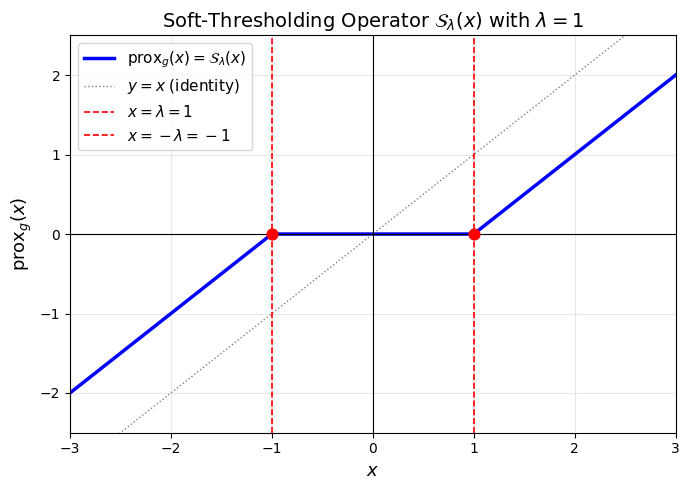

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def soft_threshold(x, lam):
    return np.sign(x) * np.maximum(np.abs(x) - lam, 0)

lam = 1.0
x_vals = np.linspace(-3, 3, 600)
y_vals = soft_threshold(x_vals, lam)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x_vals, y_vals, 'b-', linewidth=2.5, label=r'$\mathrm{prox}_g(x) = \mathcal{S}_\lambda(x)$')
ax.plot(x_vals, x_vals, 'gray', linewidth=1, linestyle=':', label=r'$y = x$ (identity)')
ax.axhline(0, color='k', linewidth=0.8)
ax.axvline(0, color='k', linewidth=0.8)
ax.axvline(lam,  color='r', linestyle='--', linewidth=1.2, label=r'$x = \lambda = 1$')
ax.axvline(-lam, color='r', linestyle='--', linewidth=1.2, label=r'$x = -\lambda = -1$')
ax.scatter([-lam, lam], [0, 0], color='r', s=60, zorder=5)  # threshold points
ax.set_xlabel('$x$', fontsize=13)
ax.set_ylabel(r'$\mathrm{prox}_g(x)$', fontsize=13)
ax.set_title(r'Soft-Thresholding Operator $\mathcal{S}_\lambda(x)$ with $\lambda = 1$', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(-3, 3)
ax.set_ylim(-2.5, 2.5)
plt.tight_layout()
plt.show()

### Question 2 (10 points): Separability of the Proximal Operator

**Claim:** If $f : \mathbb{R}^n \to \mathbb{R}$ is proper, closed, and convex with $f(x) = \sum_{i=1}^n g_i(x_i)$, where each $g_i : \mathbb{R} \to \mathbb{R}$ is proper, closed, and convex, then:
$$\text{prox}_f(x) = \left[\text{prox}_{g_i}(x_i)\right]_{i=1}^n$$

**Proof:**

By definition of the proximal operator:
$$\text{prox}_f(x) = \arg\min_{y \in \mathbb{R}^n} \left\{ f(y) + \frac{1}{2}\|y - x\|_2^2 \right\}$$

Substituting the separable form of $f$ and expanding the squared norm:
$$= \arg\min_{y} \left\{ \sum_{i=1}^n g_i(y_i) + \frac{1}{2}\sum_{i=1}^n (y_i - x_i)^2 \right\} = \arg\min_{y} \sum_{i=1}^n \left\{ g_i(y_i) + \frac{1}{2}(y_i - x_i)^2 \right\}$$

The objective is a sum of $n$ terms, each depending on a **distinct** coordinate $y_i$. Therefore the joint minimization fully decouples into $n$ independent scalar minimizations:
$$y_i^* = \arg\min_{y_i \in \mathbb{R}} \left\{ g_i(y_i) + \frac{1}{2}(y_i - x_i)^2 \right\} = \text{prox}_{g_i}(x_i), \qquad i = 1, \ldots, n$$

To see this rigorously, the first-order optimality condition for the full problem requires $0 \in \partial_y \phi(y)$, where $\phi(y) = \sum_{i=1}^n \left[g_i(y_i) + \frac{1}{2}(y_i - x_i)^2\right]$. Computing the subdifferential component-wise:
$$\partial_y \phi(y) = \begin{bmatrix} \partial g_1(y_1) + (y_1 - x_1) \\ \vdots \\ \partial g_n(y_n) + (y_n - x_n) \end{bmatrix}$$

Each component involves only $y_i$, so the condition $0 \in \partial_y \phi(y)$ holds if and only if, for each $i$:
$$0 \in \partial g_i(y_i) + (y_i - x_i)$$

which is exactly the optimality condition for $y_i = \text{prox}_{g_i}(x_i)$. Since $g_i$ is convex, each scalar problem has a unique solution. Assembling component-wise:

$$\boxed{\text{prox}_f(x) = \left[\text{prox}_{g_i}(x_i)\right]_{i=1}^n} \qquad \square$$

### Question 3 (5 points): Proximal Operator of $r(x) = \lambda\|x\|_1$

We write $r$ in separable form:
$$r(x) = \lambda\|x\|_1 = \sum_{i=1}^n \lambda|x_i| = \sum_{i=1}^n g_i(x_i), \qquad \text{where } g_i(t) = \lambda|t|$$

Each $g_i$ is the scaled absolute value from Question 1. Applying the separability result of Question 2:
$$\text{prox}_r(x) = \left[\text{prox}_{g_i}(x_i)\right]_{i=1}^n = \left[\mathcal{S}_\lambda(x_i)\right]_{i=1}^n$$

Therefore:
$$\boxed{\left(\text{prox}_r(x)\right)_i = \mathcal{S}_\lambda(x_i) = \begin{cases} x_i - \lambda & \text{if } x_i > \lambda \\ 0 & \text{if } |x_i| \leq \lambda \\ x_i + \lambda & \text{if } x_i < -\lambda \end{cases}} \qquad i = 1, \ldots, n$$

That is, the proximal operator of the $\ell_1$ norm applies soft-thresholding independently to each coordinate.

### Question 4 (10 points): Proximal Gradient Method for Problem (1)

We decompose the objective as $F(x) = f(x) + r(x)$ where:
- $f(x) = \frac{1}{2}\|Ax - b\|_2^2$ — smooth and convex
- $r(x) = \lambda\|x\|_1$ — nonsmooth but convex

**Gradient of the smooth part:**
$$\nabla f(x) = A^\top(Ax - b)$$

**Proximal gradient iteration** with constant step size $h > 0$:
$$x_{t+1} = \text{prox}_{hr}\!\left(x_t - h\nabla f(x_t)\right) = \text{prox}_{h\lambda\|\cdot\|_1}\!\left(x_t - h A^\top(Ax_t - b)\right)$$

Let $z_t = x_t - h A^\top(Ax_t - b)$ (the gradient step). Applying the soft-thresholding proximal operator from Question 3 with threshold $h\lambda$:

$$\boxed{x_{t+1} = \mathcal{S}_{h\lambda}(z_t), \qquad \text{where} \qquad (x_{t+1})_i = \begin{cases} (z_t)_i - h\lambda & \text{if } (z_t)_i > h\lambda \\ (z_t)_i + h\lambda & \text{if } (z_t)_i < -h\lambda \\ 0 & \text{if } |(z_t)_i| \leq h\lambda \end{cases}}$$

In words: take a gradient step on the smooth part $f$, then apply component-wise soft-thresholding at level $h\lambda$ to handle the $\ell_1$ penalty.

### Question 5 (5 points): Lipschitz Constant and Step Size

The smooth part of the composite objective is $f(x) = \frac{1}{2}\|Ax - b\|_2^2$.

Computing the Hessian:
$$\nabla^2 f(x) = A^\top A$$

The Lipschitz constant $L_f$ of the gradient $\nabla f$ is the smallest constant satisfying $\|\nabla f(x) - \nabla f(y)\|_2 \leq L_f\|x-y\|_2$ for all $x, y$. Since:
$$\|\nabla f(x) - \nabla f(y)\|_2 = \|A^\top A(x - y)\|_2 \leq \|A^\top A\|_2\,\|x - y\|_2$$

and $\|A^\top A\|_2 = \lambda_{\max}(A^\top A)$ (the spectral norm equals the largest eigenvalue for PSD matrices), we obtain:

$$\boxed{L_f = \lambda_{\max}(A^\top A) = \sigma_{\max}(A)^2}$$

where $\sigma_{\max}(A)$ is the largest singular value of $A$.

The constant step size that guarantees convergence of the proximal gradient method is:
$$h = \frac{1}{L_f} = \frac{1}{\lambda_{\max}(A^\top A)}$$

### Question 6 (10 points): Subgradient Method for Problem (1)

The full objective is $F(x) = \frac{1}{2}\|Ax - b\|_2^2 + \lambda\|x\|_1$.

**Subdifferential of $F$:**

Since $f(x) = \frac{1}{2}\|Ax-b\|_2^2$ is smooth and $r(x) = \lambda\|x\|_1$ is convex, by the sum rule:
$$\partial F(x) = \nabla f(x) + \lambda\,\partial\|x\|_1 = A^\top(Ax - b) + \lambda\, s$$

where $s \in \partial\|x\|_1$ has components:
$$s_i \in \begin{cases} \{\text{sign}(x_i)\} & \text{if } x_i \neq 0 \\ [-1, 1] & \text{if } x_i = 0 \end{cases}$$

A canonical subgradient is obtained by taking $s_i = \text{sign}(x_i)$ (with $\text{sign}(0) = 0$):
$$g = A^\top(Ax - b) + \lambda\,\text{sign}(x) \in \partial F(x)$$

**Subgradient iteration** at step $t$ with constant step size $h > 0$:

$$\boxed{x_{t+1} = x_t - h\,g_t, \qquad g_t = A^\top(Ax_t - b) + \lambda\,\text{sign}(x_t) \in \partial F(x_t)}$$

**Key observation:** Unlike the proximal gradient method, the subgradient method does **not** guarantee descent at every step — $F(x_{t+1})$ may be larger than $F(x_t)$. Convergence is tracked via the best iterate: $F_{\text{best}}^{(t)} = \min_{s \leq t} F(x_s)$.

---
## Problem 1, Question 7: Numerical Experiments

### Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ── Problem data ──────────────────────────────────────────────────────────────
m, n = 100, 110
lam  = 1.0

A      = np.random.randn(m, n)
x_true = np.zeros(n)
x_true[2] =  1.0   # e_3  (0-indexed)
x_true[6] = -1.0   # -e_7 (0-indexed)
b  = A @ x_true
x0 = np.ones(n)

# ── Helper functions ──────────────────────────────────────────────────────────
def F(x):
    """Full objective F(x) = (1/2)||Ax-b||^2 + λ||x||_1."""
    return (1/2)*((A@x-b).T@(A@x-b)) + lam*np.linalg.norm(x, 1)

def grad_f(x):
    """Gradient of smooth part: ∇f(x) = A^T(Ax - b)."""
    return A.T @ (A@x - b)

def soft_threshold(x, threshold):
    """Component-wise soft-thresholding S_threshold(x)."""
    return np.sign(x) * np.maximum(np.abs(x) - threshold, 0)

# ── Lipschitz constant & step size (Q5) ──────────────────────────────────────
L_f    = np.linalg.eigvalsh(A.T @ A).max()
h_prox = 1 / L_f

# ── Surrogate for F* ──────────────────────────────────────────────────────────
F_star = F(x_true)

### (a) Subgradient Method with Polyak Step Size

$$x_{t+1} = x_t - h_t g_t, \qquad h_t = \frac{F(x_t) - F^*}{\|g_t\|^2} \quad (g_t \neq 0)$$

In [3]:
def subgradient_polyak(x0, T=200):
    x = x0.copy()
    F_vals, dist_vals = [], []

    for t in range(T):
        F_vals.append(F(x))
        dist_vals.append(np.linalg.norm(x - x_true))

        # TODO: compute subgradient g_t ∈ ∂F(x_t)
        g_t = grad_f(x)+lam*np.sign(x) # this feels wrong 

        # TODO: compute Polyak step size h_t = (F(x_t) - F*) / ||g_t||^2
        h_t = (F(x)-F_star)/np.linalg.norm(g_t)**2

        # TODO: update x
        x = x - h_t*g_t

    F_vals.append(F(x))
    dist_vals.append(np.linalg.norm(x - x_true))
    return np.array(F_vals), np.array(dist_vals)


F_sub, dist_sub = subgradient_polyak(x0)

### (b) Proximal Gradient Method

$$x_{t+1} = \mathcal{S}_{h\lambda}\!\left(x_t - h A^\top(Ax_t - b)\right), \qquad h = \frac{1}{L_f}$$

In [4]:
def proximal_gradient(x0, h, T=200):
    x = x0.copy()
    F_vals, dist_vals = [], []

    for t in range(T):
        F_vals.append(F(x))
        dist_vals.append(np.linalg.norm(x - x_true))

        z = x - h * grad_f(x)
        x = soft_threshold(z, h * lam)

    F_vals.append(F(x))
    dist_vals.append(np.linalg.norm(x - x_true))
    return np.array(F_vals), np.array(dist_vals)


F_prox, dist_prox = proximal_gradient(x0, h=h_prox)

### (c) Plots: $F(x_t) - F^*$ and $\|x_t - x_\text{true}\|_2$ over 200 iterations

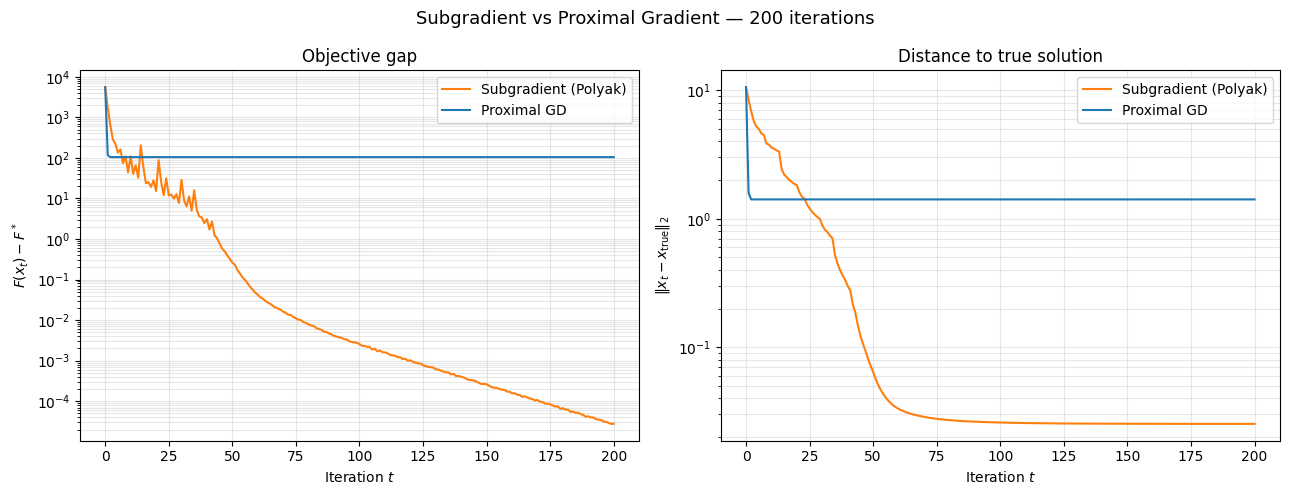

In [5]:
iters = np.arange(201)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(iters, F_sub  - F_star, label='Subgradient (Polyak)', color='tab:orange')
axes[0].semilogy(iters, F_prox - F_star, label='Proximal GD',          color='tab:blue')
axes[0].set_xlabel('Iteration $t$')
axes[0].set_ylabel('$F(x_t) - F^*$')
axes[0].set_title('Objective gap')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

axes[1].semilogy(iters, dist_sub,  label='Subgradient (Polyak)', color='tab:orange')
axes[1].semilogy(iters, dist_prox, label='Proximal GD',          color='tab:blue')
axes[1].set_xlabel('Iteration $t$')
axes[1].set_ylabel(r'$\|x_t - x_\mathrm{true}\|_2$')
axes[1].set_title('Distance to true solution')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle('Subgradient vs Proximal Gradient — 200 iterations', fontsize=13)
plt.tight_layout()
plt.show()

### (d) Bonus: Accelerated Proximal Gradient (FISTA)

Initialize $x_0 = y_0$, $\alpha_0 = 1$. At each iteration:
$$x_{t+1} = \mathcal{S}_{h\lambda}(y_t - h\nabla f(y_t)), \qquad \alpha_{t+1} = \frac{1 + \sqrt{1 + 4\alpha_t^2}}{2}, \qquad y_{t+1} = x_{t+1} + \frac{\alpha_t - 1}{\alpha_t+1}(x_{t+1} - x_t)$$

In [7]:
def accelerated_proximal_gradient(x0, h, T=200):
    x     = x0.copy()
    y     = x0.copy()
    alpha = 1.0
    F_vals, dist_vals = [], []

    for t in range(T):
        F_vals.append(F(x))
        dist_vals.append(np.linalg.norm(x - x_true))

        # TODO: proximal step from momentum point y_t
        x_new = soft_threshold(y-h*grad_f(y),h*lam)

        # TODO: update momentum coefficient α_{t+1}
        alpha_new = (1+np.sqrt(1+4*np.pow(alpha,2)))/2

        # TODO: extrapolation step to get y_{t+1}
        y_new = x_new + (alpha-1)/(alpha+1)*(x_new-x)

        x     = x_new
        alpha = alpha_new
        y = y_new

    F_vals.append(F(x))
    dist_vals.append(np.linalg.norm(x - x_true))
    return np.array(F_vals), np.array(dist_vals)


F_fista, dist_fista = accelerated_proximal_gradient(x0, h=h_prox)

### (e) Bonus: All Three Algorithms Compared

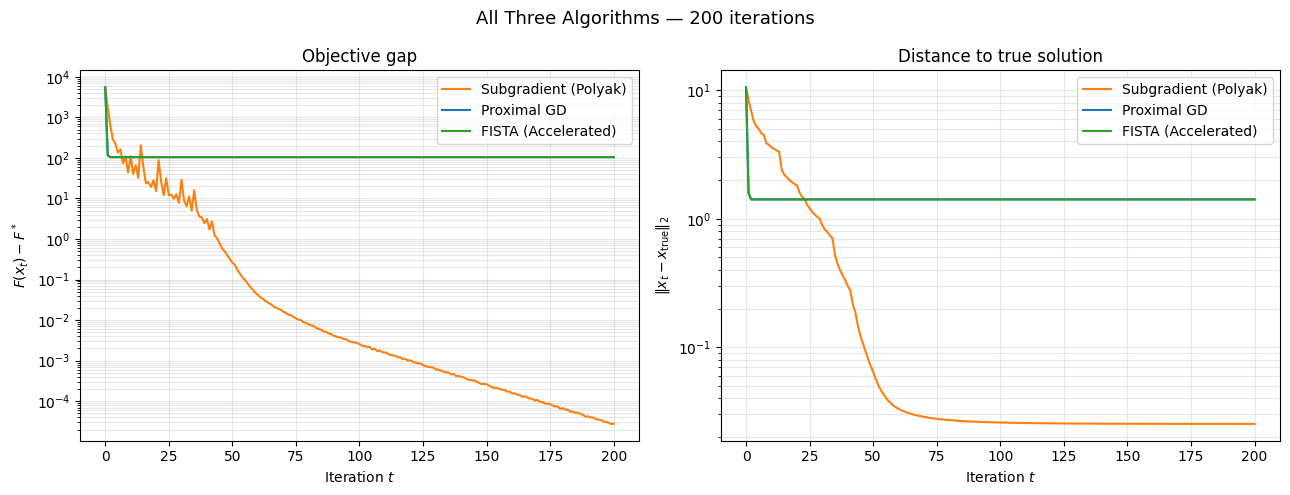

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(iters, F_sub   - F_star, label='Subgradient (Polyak)', color='tab:orange')
axes[0].semilogy(iters, F_prox  - F_star, label='Proximal GD',          color='tab:blue')
axes[0].semilogy(iters, F_fista - F_star, label='FISTA (Accelerated)',   color='tab:green')
axes[0].set_xlabel('Iteration $t$')
axes[0].set_ylabel('$F(x_t) - F^*$')
axes[0].set_title('Objective gap')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

axes[1].semilogy(iters, dist_sub,   label='Subgradient (Polyak)', color='tab:orange')
axes[1].semilogy(iters, dist_prox,  label='Proximal GD',          color='tab:blue')
axes[1].semilogy(iters, dist_fista, label='FISTA (Accelerated)',   color='tab:green')
axes[1].set_xlabel('Iteration $t$')
axes[1].set_ylabel(r'$\|x_t - x_\mathrm{true}\|_2$')
axes[1].set_title('Distance to true solution')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle('All Three Algorithms — 200 iterations', fontsize=13)
plt.tight_layout()
plt.show()